### Multilayer ANN

- More terminology of DL
- About implementing multilayer ANN model

Layers in DL networks
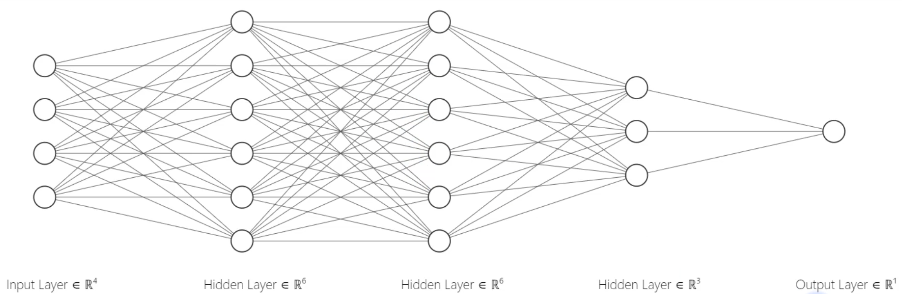



In [1]:
# libraries import
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

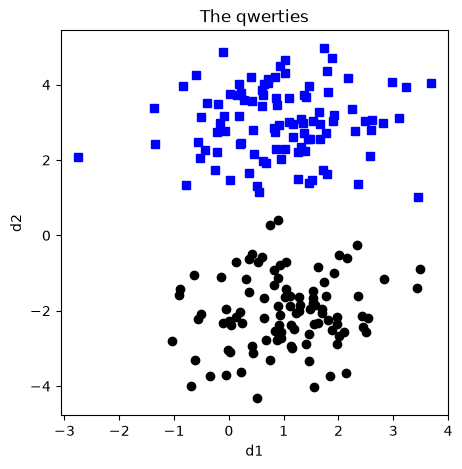

In [2]:
# create data

nPerClust = 100
blur = 1

#specify the center of the data clouds
A = [1,3]
B = [1,-2]

# generate data
a = [A[0]+np.random.randn(nPerClust)*blur, A[1]+np.random.randn(nPerClust)*blur]
b = [B[0]+np.random.randn(nPerClust)*blur, B[1]+np.random.randn(nPerClust)*blur]

# true labels
labels_np = np.vstack((np.zeros((nPerClust,1)), np.ones((nPerClust,1))))
# I'm categoryze the data using the sentence above

# concatanate into a matrix
data_np = np.hstack((a,b)).T

# convert to a pytorch tensor
data = torch.tensor(data_np).float()
labels = torch.tensor(labels_np).float()

# show the data
fig = plt.figure(figsize=(5,5))
plt.plot(data[np.where(labels==0)[0],0],data[np.where(labels==0)[0],1],'bs')
plt.plot(data[np.where(labels==1)[0],0],data[np.where(labels==1)[0],1],'ko')
plt.title('The qwerties')
plt.xlabel('d1')
plt.ylabel('d2')
plt.show()

### Function to build and train the model 

In [3]:
def createANNmodel(learningRate):

    # model architecture
    ANNclassify = nn.Sequential(
        nn.Linear(2,16), # input layer
        nn.ReLU(),       # activation function
        nn.Linear(16,1), # hidden layer
        nn.ReLU(),       # activation function
        nn.Linear(1,1),  # output layer
        nn.Sigmoid()     # activation function
    )
    # so the model is a sequency of layers, the first layer is a linear layer with 2 inputs and 16 outputs, the second layer is a ReLU activation function, the third layer is a linear layer with 16 inputs and 1 output, the fourth layer is a ReLU activation function, the fifth layer is a linear layer with 1 input and 1 output, and the sixth layer is a Sigmoid activation function. It's important to note that the linear layers need the same lines and columns, because the multiplication matrix needs to be valid.

    # loss function
    lossfun = nn.BCELoss() 
    # but better to use nn.BCEWithLogitsLoss() because it is more numerically stable

    # optimizer
    optimizer = torch.optim.SGD(ANNclassify.parameters(), lr=learningRate)

    # model output
    return ANNclassify, lossfun, optimizer


In [6]:
# a function that train the model

# a fixed parameter for the training
numepochs = 1000

def trainModel(ANNmodel):

    # initialize the losses
    losses = torch.zeros(numepochs)

    # loop over epochs
    for epochi in range(numepochs):
        # forward pass
        yHat = ANNmodel(data)

        # compute loss
        loss = lossfun(yHat, labels)
        # save loss
        losses[epochi] = loss

        # zero the gradients
        optimizer.zero_grad()
        # backward pass
        loss.backward()
        # update weights
        optimizer.step()

    # final forward pass
    predictions = ANNmodel(data)

    # compute the predictions and report accuracy
    totalacc = 100*torch.mean(((predictions>.5) == labels).float())
    # note, how the output of the model is sigmoid, so the output is between 0 and 1, so we can use a threshold of 0.5 to classify the data. If the output has been trained with linear activation function, then we can use a threshold of 0 to classify the data.

    return losses, predictions, totalacc
